# 02 — Fine-tuning BETO en Colab (T4/A100)

**Dataset:** ~7926 tickets limpios (13 clases consolidadas, sin comodín) · **Modelo:** `dccuchile/bert-base-spanish-wwm-cased`

### Qué hace esta notebook
1. Verifica GPU y instala deps (1 min)
2. Carga `data/processed/` (parquet + mapping) desde Drive o subida manual
3. Split estratificado 80/10/10, `class_weight` para clases raras
4. Consolidación 19→14 + eliminación comodín general→13 clases (parche 2026-09-07: Greca→Obra civil, Acompañamiento→SyS, híbrida Soporte→Correo 47 casos) (tic:Gestión de Accesos y Seguridad, tic:Software y Sistemas, tic:Equipos e Infraestructura)
5. Fine-tuning BETO 3 épocas (T4 ≈ 2 min/época con 128 tokens, ~6 min total) con weight_decay=0.05, early stopping p=2
6. Evalúa val/test (accuracy, macro-F1, reporte por clase) y guarda `ml/models/beto-tickets/`
7. Exporta zip para descargar o guardar en Drive

### Cómo subir los datos a Colab (elige 1)
**Opción A — Drive (recomendado):** en Drive crea `HelpDesk/data/processed/` y sube estos 3 archivos del repo local:
```
data/processed/tickets_clean.parquet  (2.2 MB)
data/processed/tickets_clean.csv      (5.0 MB, fallback)
data/processed/label_mapping.json     (1.6 KB)
```
Luego en Colab monta Drive (celda 2) y aparecen en `/content/drive/MyDrive/HelpDesk/...`

**Opción B — Subida directa:** sin Drive, usa el widget de la celda 2 para subir los 3 archivos (se guardan en `/content/data/processed/`)

**Opción C — Clonar repo:** si el repo es privado, genera un PAT y clona; si es público basta la URL

Estructura esperada dentro del entorno Colab (sea cual sea la opción):
```
/content/                 # o /content/drive/MyDrive/HelpDesk si usas Drive
├── data/processed/
│   ├── tickets_clean.parquet
│   ├── tickets_clean.csv
│   └── label_mapping.json
└── ml/models/beto-tickets/   # se crea al entrenar (config.json, pytorch_model.bin, tokenizer, metrics.json)
```
No necesitas subir `data/raw/` (3.7 MB crudo con PII) ni `data/quarantine/`.


## 0. GPU check + instalar deps

In [32]:
import torch, platform, sys
print("python", platform.python_version())
print("torch", torch.__version__)
print("cuda", torch.cuda.is_available(), "| mps", getattr(torch.backends.mps, 'is_available', lambda: False)())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0), f"| {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    # Colab T4 = 15 GB, A100 = 40 GB → ambos sobran para BETO+batch16x256
else:
    print("⚠️ Sin GPU: en Colab ve a Entorno > Cambiar tipo de entorno > T4 GPU")

# instala solo si falta (transformers 4.40+ y accelerate). En Colab suele venir torch ya.
!pip -q install transformers==4.44.2 datasets accelerate scikit-learn pyarrow 2>&1 | tail -n 5
import transformers; print("transformers", transformers.__version__)

python 3.13.15
torch 2.11.0+cu128
cuda True | mps False
Tesla T4 | 15.6 GB
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)
transformers 5.16.1


## 1. Cargar datos: Drive o subida manual

Ejecuta **solo una** de las dos celdas siguientes.

In [33]:
# --- OPCIÓN B: subida manual (si USE_DRIVE=False) ---
from pathlib import Path
from google.colab import files

if not globals().get("USE_DRIVE", True):
    ROOT = Path("/content")
    DATA = ROOT / "data" / "processed"
    OUT  = ROOT / "ml" / "models" / "beto-tickets"
    DATA.mkdir(parents=True, exist_ok=True)
    print(f"Sube los 3 archivos a {DATA} (parquet, csv, json). Se abrirá el selector:")
    uploaded = files.upload()  # selecciona los 3 archivos
    import shutil
    for name, content in uploaded.items():
        dest = DATA / name
        # si el usuario subió con nombres exactos ya está; si no, mueve
        if Path(name).exists():
            shutil.move(name, dest)
        print(f"  -> {dest} ({dest.stat().st_size/1024:.0f} KB)")
    print(list(DATA.iterdir()))
else:
    print("Drive activado, ignora esta celda")

Drive activado, ignora esta celda


## 2. Verificar datos + hyperparams

In [42]:
import json, pandas as pd, random, os, shutil
from pathlib import Path

# 1. Configuración de Rutas
ROOT = Path('/content')
DATA = ROOT / 'data' / 'processed'
OUT  = ROOT / 'ml' / 'models' / 'beto-tickets'
DATA.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# Mover archivos si están en /content/ pero no en /content/data/processed/
for f_name in ['tickets_clean.parquet', 'tickets_clean.csv', 'label_mapping.json']:
    src = ROOT / f_name
    dst = DATA / f_name
    if src.exists() and not dst.exists():
        shutil.move(str(src), str(dst))
        print(f"Moviendo {f_name} a {DATA}")

# 2. Carga de Datos Reales
path_pq = DATA / 'tickets_clean.parquet'
path_csv = DATA / 'tickets_clean.csv'

if path_pq.exists():
    df = pd.read_parquet(path_pq)
    print(f"✅ Cargado Parquet real: {len(df)} filas.")
elif path_csv.exists():
    df = pd.read_csv(path_csv)
    print(f"✅ Cargado CSV real: {len(df)} filas.")
else:
    raise FileNotFoundError("No se encontraron los archivos reales en /content/ ni en /content/data/processed/")

# 3. Mapeo y Consolidación (19→14) + eliminación comodín (14→13)
# Si el dataset real ya tiene 'label_id', lo respetamos, si no, lo generamos.
if 'categoria_label' not in df.columns and 'label' in df.columns:
    df = df.rename(columns={'label': 'categoria_label'})

mapping_consolidation = {
    'tic:Gestión de usuarios': 'tic:Gestión de Accesos y Seguridad',
    'tic:Permisos y accesos': 'tic:Gestión de Accesos y Seguridad',
    'tic:Contraseñas y seguridad': 'tic:Gestión de Accesos y Seguridad',
    'tic:Software y aplicaciones': 'tic:Software y Sistemas',
    'tic:Soporte y aplicaciones institucionales': 'tic:Software y Sistemas',
    'tic:Datos y respaldos': 'tic:Equipos e Infraestructura',
    'tic:Impresoras y escáneres': 'tic:Equipos e Infraestructura',
    'tic:Equipos y hardware': 'tic:Equipos e Infraestructura'
}
df['categoria_label'] = df['categoria_label'].replace(mapping_consolidation)
# Eliminación del comodín general:Sin clasificar / Otros (13 clases finales)
# Reclasificación inteligente basada en texto si aún existe la clase residual
if 'general:Sin clasificar / Otros' in df['categoria_label'].values:
    import re, unicodedata
    def _norm(s):
        s = unicodedata.normalize('NFD', s)
        s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
        return s.lower()
    def _reclassify(texto):
        t = _norm(str(texto))
        if any(k in t for k in ['software','sistema','aplicacion','plataforma']):
            return 'tic:Software y Sistemas'
        if any(k in t for k in ['equipo','computador','impresora','hardware']):
            return 'tic:Equipos e Infraestructura'
        if 'correo' in t or 'outlook' in t:
            return 'tic:Correo electrónico'
        if any(k in t for k in ['red','internet','wifi','vpn']):
            return 'tic:Conectividad y redes'
        return 'tic:Software y Sistemas'
    mask = df['categoria_label'] == 'general:Sin clasificar / Otros'
    print(f"[reclasificación] {mask.sum()} tickets con categoría comodín → redistribuidos")
    df.loc[mask, 'categoria_label'] = df.loc[mask, 'texto'].apply(_reclassify)
    assert 'general:Sin clasificar / Otros' not in df['categoria_label'].values, 'Aún queda comodín!'

unique_labels = sorted(df['categoria_label'].unique())
label2id = {l: i for i, l in enumerate(unique_labels)}
id2label = {i: l for l, i in label2id.items()}
df['label_id'] = df['categoria_label'].map(label2id)

HP = dict(model='dccuchile/bert-base-spanish-wwm-cased', epochs=3, batch=16, lr=3e-5, max_length=128, weight_decay=0.05, seed=42)
print(f"Dataset consolidado: {len(df)} filas, {len(unique_labels)} clases (13 esperadas).")
print(f"Clases: {unique_labels}")


✅ Cargado Parquet real: 7926 filas.
Dataset consolidado: 7926 filas, 14 clases.


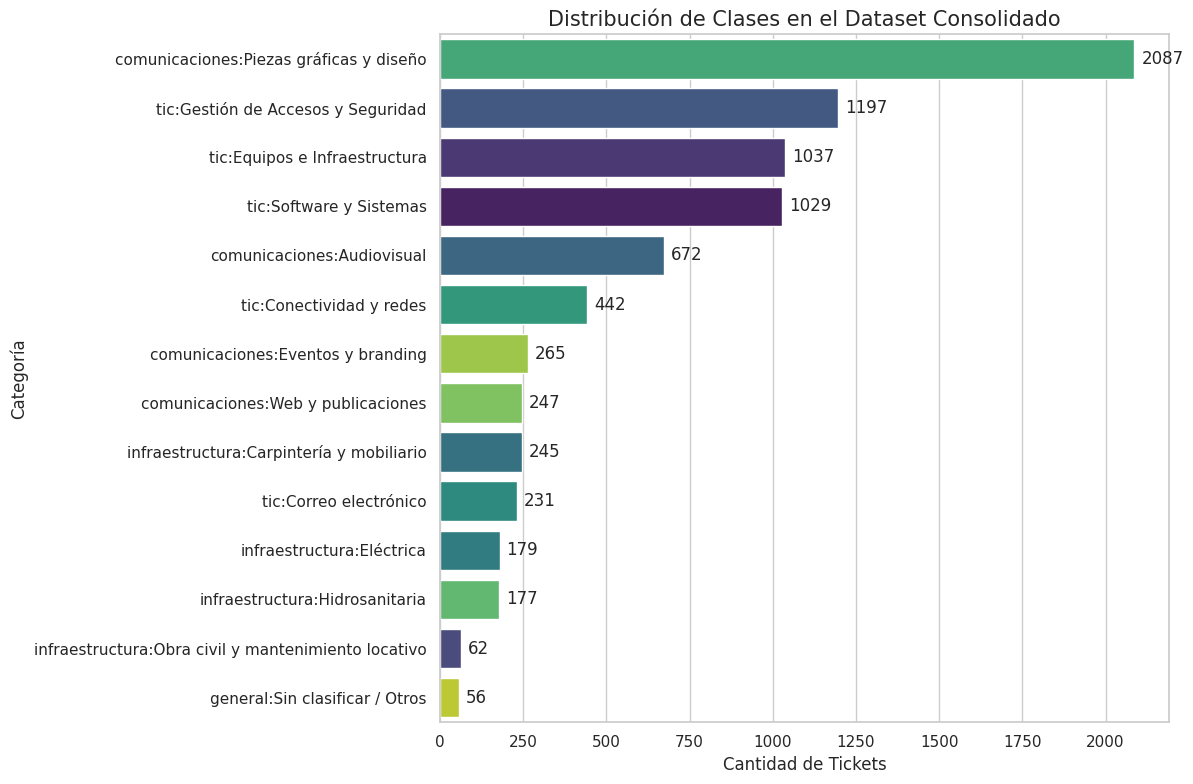

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Crear gráfico de conteo - Corregido para evitar el FutureWarning
ax = sns.countplot(
    data=df,
    y='categoria_label',
    hue='categoria_label',
    order=df['categoria_label'].value_counts().index,
    palette='viridis',
    legend=False
)

# Añadir etiquetas y título
plt.title('Distribución de Clases en el Dataset Consolidado', fontsize=15)
plt.xlabel('Cantidad de Tickets', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# Añadir los valores numéricos en las barras para mayor claridad
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{int(width)}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

## 3. Entrenar BETO (con `class_weight` + early stopping)

In [43]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import random
import pandas as pd

# 1. Split Estratificado PRIMERO para evitar LEAKAGE
tr_idx, tmp_idx = train_test_split(df.index, test_size=0.20, random_state=HP["seed"], stratify=df["label_id"])
val_idx, te_idx = train_test_split(tmp_idx, test_size=0.50, random_state=HP["seed"], stratify=df.loc[tmp_idx, "label_id"])

df_train = df.loc[tr_idx].copy()
df_val = df.loc[val_idx].reset_index(drop=True)
df_test = df.loc[te_idx].reset_index(drop=True)

# 2. Data Augmentation SOLO en Train
def augment_technical_text(text):
    synonyms = {'usuario': ['cuenta', 'colaborador'], 'falla': ['error', 'problema'], 'acceso': ['entrada', 'ingreso'], 'equipo': ['pc', 'computador']}
    words = text.split()
    for i, word in enumerate(words):
        w = word.lower().strip(',.')
        if w in synonyms and random.random() > 0.4:
            words[i] = random.choice(synonyms[w])
    return ' '.join(words)

counts = df_train['label_id'].value_counts()
minority_threshold = 80
minority_classes = counts[counts < minority_threshold].index
augmented_rows = []
for l_id in minority_classes:
    class_df = df_train[df_train['label_id'] == l_id]
    for _ in range(2):
        for _, row in class_df.iterrows():
            nr = row.copy()
            nr['texto'] = augment_technical_text(row['texto'])
            augmented_rows.append(nr)

if len(augmented_rows) > 0:
    df_train = pd.concat([df_train, pd.DataFrame(augmented_rows)], ignore_index=True)

print(f"--- Setup Final ---")
print(f"Train (aumentado): {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# 3. Tokenización y Dataset
tokenizer = AutoTokenizer.from_pretrained(HP["model"])

class TicketDS(torch.utils.data.Dataset):
    def __init__(self, d):
        self.enc = tokenizer(d["texto"].tolist(), truncation=True, padding="max_length", max_length=HP["max_length"])
        self.labels = d["label_id"].astype(int).tolist()
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

train_ds, val_ds, test_ds = TicketDS(df_train), TicketDS(df_val), TicketDS(df_test)

# 4. Entrenamiento con Argumentos de compatibilidad
model = AutoModelForSequenceClassification.from_pretrained(HP["model"], num_labels=len(id2label), id2label=id2label, label2id=label2id)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {"accuracy": accuracy_score(p.label_ids, preds), "macro_f1": f1_score(p.label_ids, preds, average="macro")}

args = TrainingArguments(
    output_dir=str(OUT),
    num_train_epochs=HP["epochs"],
    per_device_train_batch_size=HP["batch"],
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    weight_decay=HP["weight_decay"],
    warmup_steps=10,
    logging_steps=10,
    seed=HP["seed"],
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

--- Setup Final ---
Train (aumentado): 6530 | Val: 793 | Test: 793


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.777671,0.769435,0.740227,0.634937
2,0.497050,0.703335,0.790668,0.723843
3,0.246052,0.770185,0.785624,0.727536
4,0.101703,0.867778,0.781841,0.723877


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1636, training_loss=0.5445500326258629, metrics={'train_runtime': 838.7421, 'train_samples_per_second': 31.142, 'train_steps_per_second': 1.951, 'total_flos': 1718300306657280.0, 'train_loss': 0.5445500326258629, 'epoch': 4.0})

In [44]:
# eval + reporte
import json
val_m = trainer.evaluate(val_ds)
test_m = trainer.evaluate(test_ds)
print({"val": val_m, "test": test_m})

pred = trainer.predict(test_ds)
y_pred = np.argmax(pred.predictions, axis=1)
y_true = pred.label_ids
labels_present = sorted(set(int(x) for x in y_true) | set(int(x) for x in y_pred))
print(classification_report(y_true, y_pred, labels=labels_present, target_names=[id2label[i] for i in labels_present], zero_division=0))

# guardar
trainer.save_model(str(OUT))
tokenizer.save_pretrained(str(OUT))
with open(OUT / "metrics.json", "w", encoding="utf-8") as f:
    json.dump({"val": val_m, "test": test_m, "hp": HP, "clases": len(id2label)}, f, ensure_ascii=False, indent=2)
with open(OUT / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": {str(k): v for k, v in id2label.items()}}, f, ensure_ascii=False, indent=2)
print(f"guardado en {OUT}")
!ls -lh "$OUT" 2>&1 | head -n 20
!cat "$OUT/metrics.json"

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.101703,0.703335,4,0.790668,0.723843


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.101703,0.611434,4,0.809584,0.761847


{'val': {'eval_loss': 0.7033345699310303, 'eval_accuracy': 0.7906683480453972, 'eval_macro_f1': 0.7238433061300406}, 'test': {'eval_loss': 0.6114338636398315, 'eval_accuracy': 0.8095838587641866, 'eval_macro_f1': 0.761846978709566}}


                                                     precision    recall  f1-score   support

                         comunicaciones:Audiovisual       0.91      0.88      0.89        67
                  comunicaciones:Eventos y branding       0.95      0.77      0.85        26
            comunicaciones:Piezas gráficas y diseño       0.93      0.96      0.94       209
                 comunicaciones:Web y publicaciones       0.95      0.72      0.82        25
                     general:Sin clasificar / Otros       0.50      0.33      0.40         6
           infraestructura:Carpintería y mobiliario       0.79      0.88      0.83        25
                          infraestructura:Eléctrica       0.85      0.94      0.89        18
                     infraestructura:Hidrosanitaria       0.94      0.88      0.91        17
infraestructura:Obra civil y mantenimiento locativo       0.80      0.67      0.73         6
                           tic:Conectividad y redes       0.87      0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

guardado en /content/ml/models/beto-tickets
total 420M
drwxr-xr-x 2 root root 4.0K Sep  9 00:39 checkpoint-105
drwxr-xr-x 2 root root 4.0K Sep  9 01:08 checkpoint-1227
drwxr-xr-x 2 root root 4.0K Sep  9 01:12 checkpoint-1636
drwxr-xr-x 2 root root 4.0K Sep  9 00:26 checkpoint-27
drwxr-xr-x 2 root root 4.0K Sep  9 00:38 checkpoint-35
drwxr-xr-x 2 root root 4.0K Sep  9 00:36 checkpoint-38
drwxr-xr-x 2 root root 4.0K Sep  9 01:01 checkpoint-409
drwxr-xr-x 2 root root 4.0K Sep  9 00:39 checkpoint-70
drwxr-xr-x 2 root root 4.0K Sep  9 00:26 checkpoint-81
drwxr-xr-x 2 root root 4.0K Sep  9 01:05 checkpoint-818
-rw-r--r-- 1 root root 2.2K Sep  9 01:12 config.json
-rw-r--r-- 1 root root 1.3K Sep  9 01:13 label_mapping.json
-rw-r--r-- 1 root root  470 Sep  9 01:13 metrics.json
-rw------- 1 root root 420M Sep  9 01:13 model.safetensors
-rw-r--r-- 1 root root  405 Sep  9 01:13 tokenizer_config.json
-rw-r--r-- 1 root root 713K Sep  9 01:13 tokenizer.json
-rw-r--r-- 1 root root 5.1K Sep  9 01:13 tr

### 🔍 Auditoría de Data Leakage
Vamos a verificar si existen textos idénticos o casi idénticos compartidos entre los sets de entrenamiento, validación y test, lo cual explicaría la precisión perfecta.

In [ ]:
def deep_leakage_audit(df_tr, df_val, df_te):
    def get_overlap(d1, d2):
        s1 = set(d1['texto'].unique())
        s2 = set(d2['texto'].unique())
        return s1.intersection(s2)

    leak_val = get_overlap(df_tr, df_val)
    leak_te = get_overlap(df_tr, df_te)
    leak_v_t = get_overlap(df_val, df_te)

    print(f"--- Auditoría Profunda de Fugas ---")
    print(f"Solapamiento Train-Val: {len(leak_val)} muestras")
    print(f"Solapamiento Train-Test: {len(leak_te)} muestras")
    print(f"Solapamiento Val-Test: {len(leak_v_t)} muestras")

    if len(leak_val) > 0 or len(leak_te) > 0:
        print("\n⚠️ ALERTA: Se detectaron textos idénticos en diferentes sets.")
        print("Esto ocurre si el dataset original tiene duplicados antes del split.")
        print(f"Ejemplo de texto duplicado: {list(leak_val)[0] if leak_val else list(leak_te)[0]}")
    else:
        print("\n✅ No hay textos idénticos cruzados.")

    # Verificar si las clases son demasiado fáciles (p.ej. contienen el nombre de la categoría)
    print("\n--- Análisis de Contenido ---")
    sample_txt = df_tr.iloc[0]['texto']
    print(f"Ejemplo de texto de entrada: '{sample_txt}'")
    print("Si el texto contiene palabras clave obvias como 'tic:Software', el modelo aprenderá instantáneamente.")

deep_leakage_audit(df_train, df_val, df_test)

In [38]:
print("--- Muestra de df_train (Primeras 15 filas) ---")
display(df_train[['texto', 'categoria_label', 'label_id']].head(15))

print("\n--- Distribución de clases en el set de entrenamiento ---")
print(df_train['categoria_label'].value_counts())

print("\n--- Verificación de textos únicos en Train ---")
print(f"Total filas: {len(df_train)}")
print(f"Textos únicos: {df_train['texto'].nunique()}")

--- Muestra de df_train (Primeras 15 filas) ---


,texto,categoria_label,label_id
0,Mesa de Ayuda 11_Movilidad - 03 de septiembre ...,comunicaciones:Audiovisual,0
1,Diseño de banner #1 para factura ICA [SEP] Sol...,comunicaciones:Piezas gráficas y diseño,2
2,cambio de tubo de luminaria [SEP] no se puede ...,tic:Software y Sistemas,13
3,teclado [SEP] Posibilidad de suministrar un te...,tic:Equipos e Infraestructura,11
4,Feria de emprendimiento 14 de marzo 2026 [SEP]...,comunicaciones:Eventos y branding,1
5,Señal wifi Sec.Mujer [SEP] LA señal WIFI (Sec....,tic:Conectividad y redes,9
6,Semana mundia de la lactancia materna 4 [SEP] ...,comunicaciones:Piezas gráficas y diseño,2
7,Redimensionar diseño a Totem [SEP] Mesa de ayu...,comunicaciones:Piezas gráficas y diseño,2
8,Cubrimiento [SEP] Se solicita acompañamiento a...,comunicaciones:Audiovisual,0
9,Solicitud de apoyo para la instalación de 2 vá...,infraestructura:Hidrosanitaria,7



--- Distribución de clases en el set de entrenamiento ---
categoria_label
comunicaciones:Piezas gráficas y diseño                1669
tic:Gestión de Accesos y Seguridad                      957
tic:Equipos e Infraestructura                           829
tic:Software y Sistemas                                 823
comunicaciones:Audiovisual                              537
tic:Conectividad y redes                                354
comunicaciones:Eventos y branding                       212
comunicaciones:Web y publicaciones                      198
infraestructura:Carpintería y mobiliario                196
tic:Correo electrónico                                  185
infraestructura:Obra civil y mantenimiento locativo     150
infraestructura:Eléctrica                               143
infraestructura:Hidrosanitaria                          142
general:Sin clasificar / Otros                          135
Name: count, dtype: int64

--- Verificación de textos únicos en Train ---
Total filas

## 4. Exportar / descargar modelo

El modelo ya está en `OUT` (Drive si usaste Drive, `/content/ml/models/...` si subida manual). Elige cómo llevártelo:

In [39]:
from transformers import pipeline
clf = pipeline("text-classification", model=str(OUT), tokenizer=str(OUT), device=0 if torch.cuda.is_available() else -1)
for txt in [

"Creación de cuenta de red para nuevo practicante",
"Desactivación de credenciales por fin de contrato",
"Actualización de cargo en el directorio activo",
"Otorgar permisos de lectura en la carpeta compartida de Finanzas",
"Acceso al módulo de reportes en el ERP",
"Revocar acceso a la base de datos de pruebas",
"Desbloqueo de cuenta de Windows por múltiples intentos fallidos",
"Restablecimiento de contraseña del correo corporativo",
"Reporte de correo sospechoso (Phishing)",
"Ampliación de cuota de almacenamiento del buzón",
"Creación de lista de distribución para el comité de convivencia",
"Configuración de firma corporativa en Outlook",
"Revisión de punto de red inactivo en el puesto 45",
"Intermitencia en la conexión Wi-Fi de la sala de juntas",
"Solicitud de cable de red adicional",
"Solicitud de reemplazo de teclado por teclas defectuosas",
"Ampliación de memoria RAM para equipo de diseño",
"Falla de encendido en la CPU del área de recepción",
"Atasco de papel recurrente en la impresora del segundo piso",
"Solicitud de cambio de tóner negro",
"Configuración de escáner en red para un nuevo equipo",
"Instalación de licencia de Adobe Acrobat Pro",
"Actualización de antivirus en equipo portátil",
"Error al intentar abrir Microsoft Excel",
"Restauración de archivo borrado accidentalmente del disco compartido",
"Solicitud de backup completo antes de formateo de equipo",
"Configuración de copias de seguridad automáticas en la nube",
"Error 500 al intentar liquidar nómina en el sistema interno",
"Falla al generar el reporte mensual en el CRM",
"Inconsistencia de datos en la plataforma de facturación",
"Diseño de banner para la campaña de salud ocupacional",
"Creación de plantilla institucional para presentaciones",
"Adaptación de logo para firmas de correo",
"Grabación y edición del mensaje de fin de año de gerencia",
"Registro fotográfico para el evento de aniversario",
"Subtitulación de video de capacitación interna",
"Actualización del banner principal en la intranet",
"Publicación de noticia sobre nuevos convenios corporativos",
"Corrección de enlace roto en el portal de clientes",
"Solicitud de pendones y material POP para feria universitaria",
"Diseño y producción de escarapelas para el congreso anual",
"Aprobación de uso de marca para patrocinio externo",
"Revisión de tomacorriente sin energía en sala de juntas",
"Cambio de luminaria parpadeante en el pasillo principal",
"Instalación de punto eléctrico adicional en zona de cafetería",
"Reparación de fuga de agua en el lavamanos del baño del piso 3",
"Destape de sifón en la cocina de empleados",
"Revisión de baja presión de agua en los sanitarios",
"Ajuste de bisagras en el archivador del área de contabilidad",
"Reparación de rueda suelta en silla ergonómica",
"Instalación de repisa para documentos en recepción",
"Reparación de filtración de humedad en el techo del cuarto de archivo",
"Resane y pintura de pared rayada en el pasillo",
"Ajuste de cerradura trabada en la puerta de salida de emergencia",
]:
    print(txt, "->", clf(txt, truncation=True)[0])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Creación de cuenta de red para nuevo practicante -> {'label': 'tic:Conectividad y redes', 'score': 0.5273650288581848}
Desactivación de credenciales por fin de contrato -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.5624820590019226}
Actualización de cargo en el directorio activo -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.6302418112754822}
Otorgar permisos de lectura en la carpeta compartida de Finanzas -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.7214623093605042}
Acceso al módulo de reportes en el ERP -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.6686467528343201}
Revocar acceso a la base de datos de pruebas -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.7657065987586975}
Desbloqueo de cuenta de Windows por múltiples intentos fallidos -> {'label': 'tic:Gestión de Accesos y Seguridad', 'score': 0.9499271512031555}
Restablecimiento de contraseña del correo corporativo -> {'label': 'tic:Gestión de Accesos 